In [1]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.7 MB/s eta 0:00:00


In [2]:
!wget -O reviews_Electronics_5.json.gz \
http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz

--2026-06-13 05:56:41--  http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 495854086 (473M) [application/x-gzip]
Saving to: ‘reviews_Electronics_5.json.gz’

reviews_Electronics 100%[===================>] 472.88M  9.35MB/s    in 45s     

2026-06-13 05:57:26 (10.4 MB/s) - ‘reviews_Electronics_5.json.gz’ saved [495854086/495854086]



In [3]:
import gzip
import json
import pandas as pd

data = []

with gzip.open('reviews_Electronics_5.json.gz', 'rt') as f:
    for line in f:
        review = eval(line)
        data.append([
            review['reviewerID'],
            review['asin'],
            review['overall']
        ])

df = pd.DataFrame(
    data,
    columns=['user_id', 'product_id', 'rating']
)

print(df.shape)
df.head()

(1689188, 3)


,user_id,product_id,rating
0,AO94DHGC771SJ,0528881469,5.0
1,AMO214LNFCEI4,0528881469,1.0
2,A3N7T0DY83Y4IG,0528881469,3.0
3,A1H8PY3QHMQQA0,0528881469,2.0
4,A24EV6RXELQZ63,0528881469,1.0


In [4]:
df = df.sample(100000, random_state=42)

print(df.shape)

(100000, 3)


In [5]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(1,5))

dataset = Dataset.load_from_df(
    df[['user_id','product_id','rating']],
    reader
)

In [6]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42
)

In [7]:
from surprise import SVD

model = SVD()

model.fit(trainset)

In [8]:
from surprise.accuracy import rmse

predictions = model.test(testset)

rmse(predictions)

RMSE: 1.1618


np.float64(1.1618316291228552)

In [9]:
def recommend_products(user_id, df, model, top_n=5):

    all_products = df['product_id'].unique()

    user_products = df[df['user_id']==user_id]['product_id'].unique()

    candidate_products = [
        p for p in all_products
        if p not in user_products
    ]

    preds = []

    for product in candidate_products:
        pred = model.predict(user_id, product)
        preds.append((product, pred.est))

    preds.sort(key=lambda x:x[1], reverse=True)

    return preds[:top_n]

In [10]:
sample_user = df['user_id'].iloc[0]

recommendations = recommend_products(
    sample_user,
    df,
    model,
    top_n=10
)

print("Recommendations for User:", sample_user)

for product, score in recommendations:
    print(f"{product} --> Predicted Rating: {score:.2f}")

Recommendations for User: A3E3VF85DAW0FU
B008LTBITY --> Predicted Rating: 5.00
B004S4R5CK --> Predicted Rating: 5.00
B000067SMH --> Predicted Rating: 5.00
B001MSU1FS --> Predicted Rating: 5.00
B008JJLW4M --> Predicted Rating: 5.00
B002V88HFE --> Predicted Rating: 4.98
B007SZ0E1K --> Predicted Rating: 4.96
B004LTEUDO --> Predicted Rating: 4.95
B006U3O566 --> Predicted Rating: 4.93
B001MX5YWI --> Predicted Rating: 4.92


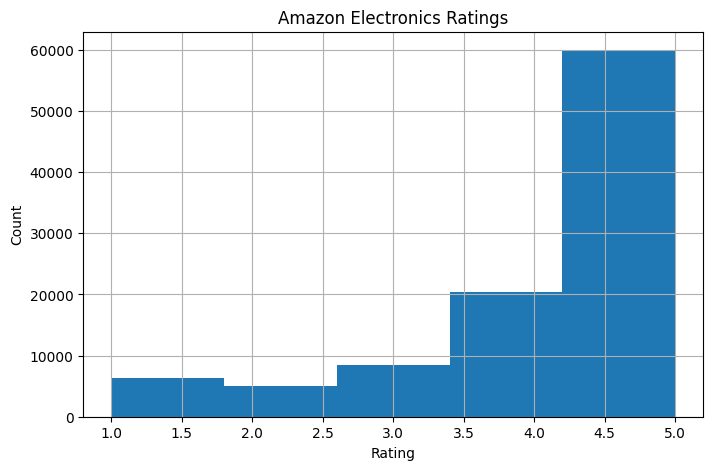

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['rating'].hist(bins=5)
plt.title("Amazon Electronics Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()